# DS3040 – Lab Assignment 5: Recurrent Neural Networks
### Complete Solution with Deep Explanations
---
## 🧠 PART 0 – Conceptual Foundation (Read Before Coding)

### What Problem Are RNNs Solving?

Imagine you're reading: *"The cat sat on the ___"*

A standard feedforward neural network sees only ONE fixed-size input vector. It has no memory of previous words.  
An **RNN** processes sequences one element at a time and carries a **hidden state** (memory) from step to step.

```
Standard NN:   [w1, w2, w3, w4] → NN → output
                (all words at once, fixed window)

RNN:           w1 → RNN → h1
                         ↓
               w2 → RNN → h2
                         ↓
               w3 → RNN → h3 → output
```

### The RNN Equation (Intuition → Math)

**Intuition:** At each step, mix the *new input* with *what you remember* to produce a new memory.

**Math:**  
`h_t = tanh(W_h * h_{t-1} + W_x * x_t + b)`

- `x_t` = current word embedding  
- `h_{t-1}` = previous hidden state (memory)  
- `W_h`, `W_x` = learnable weight matrices  
- `tanh` = keeps values between -1 and 1 (prevents explosion)

### The Vanishing Gradient Problem (Why RNN Fails on Long Sequences)

During backpropagation through time (BPTT), gradients are multiplied at every time step.  
If weights < 1, gradients → 0 exponentially. Early words are "forgotten".

```
Step 100 → Step 50 → Step 1
  grad × 0.9^50 = 0.005  (nearly zero!)
```

### LSTM: The Solution

LSTM adds a **cell state** (a 'conveyor belt') that carries information with minimal modification.  
Three gates control what flows:

| Gate | Symbol | Purpose |
|------|--------|---------|
| Forget Gate | f_t | What to erase from cell state |
| Input Gate  | i_t | What new info to write |
| Output Gate | o_t | What to expose as hidden state |

**Key insight:** Gates use sigmoid (0 to 1) to act like soft switches.  
Gradients flow through the cell state almost unchanged → solves vanishing gradient.

---

In [1]:
# ============================================================
# CELL 1 – Install & Import All Dependencies
# ============================================================
# Run this cell first. It sets up everything needed for the lab.

# If running for the first time, uncomment and run:
# !pip install torch torchvision nltk pandas scikit-learn matplotlib
# import nltk
# nltk.download('gutenberg')
# nltk.download('punkt')

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

import nltk
from nltk.corpus import gutenberg

from sklearn.model_selection import train_test_split
from collections import Counter

# ─── Reproducibility ─────────────────────────────────────────
# Setting seeds ensures your results are reproducible.
# Without this, every run gives slightly different results.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── Device configuration ────────────────────────────────────
# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.6.0+cpu


---
## Question 1 – Next-Word Prediction using RNN and LSTM
### Conceptual Overview

**Task:** Given a sequence of words, predict the next word.

**Pipeline:**
```
Raw text  →  Tokenize  →  Build vocab  →  Create sequences
          →  Embed words  →  RNN/LSTM  →  Predict next word
```

**What is an Embedding?**  
Words can't be fed directly into a neural network (they're strings).  
We map each word to a dense vector of floats.  
Example: `"king"` → `[0.2, -0.5, 0.8, ...]` (embedding_dim numbers)  
These vectors are *learned* during training — similar words end up close in vector space.

**Why Embedding > One-Hot?**  
One-hot: vocabulary size = 10,000 → each word is a 10,000-dim sparse vector (wasteful).  
Embedding: each word is a 64-dim dense vector (efficient, and captures semantic relationships).

In [5]:
# ============================================================
# CELL 2 – Q1(a): Load and Preprocess Shakespeare's Hamlet
# ============================================================

# Load the raw text
with open("hamlet.txt") as f:
    raw_text = f.read()
print(f"\nRaw text length: {len(raw_text)} characters")
print(f"\nFirst 500 chars:\n{raw_text[:500]}")


Raw text length: 191726 characters

First 500 chars:
THE TRAGEDY OF HAMLET, PRINCE OF DENMARK


by William Shakespeare



Dramatis Personae

  Claudius, King of Denmark.
  Marcellus, Officer.
  Hamlet, son to the former, and nephew to the present king.
  Polonius, Lord Chamberlain.
  Horatio, friend to Hamlet.
  Laertes, son to Polonius.
  Voltemand, courtier.
  Cornelius, courtier.
  Rosencrantz, courtier.
  Guildenstern, courtier.
  Osric, courtier.
  A Gentleman, courtier.
  A Priest.
  Marcellus, officer.
  Bernardo, officer.
  Francisco, a so


In [6]:
# ─── Preprocessing ───────────────────────────────────────────
# WHY PREPROCESS?
# - Raw text has punctuation, numbers, stage directions, etc.
# - Inconsistent casing means 'The' and 'the' are different tokens.
# - We want a clean, consistent vocabulary.

def preprocess_text(text):
    """
    Clean text for language modeling.
    Steps:
    1. Lowercase everything → 'The' and 'the' are same token
    2. Remove non-alphabetic chars (keep spaces) → remove punctuation/numbers
    3. Collapse multiple spaces → clean tokenization
    """
    text = text.lower()                          # Step 1: lowercase
    text = re.sub(r'[^a-z\s]', '', text)         # Step 2: keep only a-z and spaces
    text = re.sub(r'\s+', ' ', text).strip()     # Step 3: normalize whitespace
    return text

clean_text = preprocess_text(raw_text)
words = clean_text.split()  # Tokenize by whitespace

print(f"Total words (tokens): {len(words)}")
print(f"First 30 tokens: {words[:30]}")

# Vocabulary size
unique_words = set(words)
print(f"Unique words (vocabulary size): {len(unique_words)}")

Total words (tokens): 31946
First 30 tokens: ['the', 'tragedy', 'of', 'hamlet', 'prince', 'of', 'denmark', 'by', 'william', 'shakespeare', 'dramatis', 'personae', 'claudius', 'king', 'of', 'denmark', 'marcellus', 'officer', 'hamlet', 'son', 'to', 'the', 'former', 'and', 'nephew', 'to', 'the', 'present', 'king', 'polonius']
Unique words (vocabulary size): 4789


In [7]:
# ============================================================
# CELL 3 – Q1(b): Tokenize, Build Vocab, Create Sequences
# ============================================================

# ─── Step 1: Build Vocabulary ────────────────────────────────
# We need integer indices for each word because NNs work with numbers.
# word2idx: 'hamlet' → 5
# idx2word: 5 → 'hamlet'

# Count word frequencies
word_counts = Counter(words)

# Keep only words appearing more than MIN_FREQ times
# WHY? Rare words add noise and inflate vocab size without helping the model learn patterns.
MIN_FREQ = 2
vocab = [word for word, count in word_counts.items() if count >= MIN_FREQ]
vocab = sorted(vocab)  # Sort for reproducibility

# Add special tokens:
# <PAD>: padding token (fill shorter sequences to same length)
# <UNK>: unknown token (words not in vocabulary at inference time)
special_tokens = ['<PAD>', '<UNK>']
vocab = special_tokens + vocab

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX = word2idx['<PAD>']  # = 0
UNK_IDX = word2idx['<UNK>']  # = 1

print(f"Vocabulary size (after filtering): {VOCAB_SIZE}")
print(f"PAD index: {PAD_IDX}, UNK index: {UNK_IDX}")
print(f"Sample: 'hamlet' → index {word2idx.get('hamlet', UNK_IDX)}")

Vocabulary size (after filtering): 1936
PAD index: 0, UNK index: 1
Sample: 'hamlet' → index 714


In [8]:
# ─── Step 2: Convert words to integers ───────────────────────
def encode(word):
    return word2idx.get(word, UNK_IDX)  # Return UNK if word not in vocab

encoded_words = [encode(w) for w in words]
print(f"Total encoded tokens: {len(encoded_words)}")
print(f"First 10 encoded: {encoded_words[:10]}")
print(f"Corresponding words: {[idx2word[i] for i in encoded_words[:10]]}")

Total encoded tokens: 31946
First 10 encoded: [1639, 1705, 1126, 714, 1263, 1126, 386, 229, 1, 1]
Corresponding words: ['the', 'tragedy', 'of', 'hamlet', 'prince', 'of', 'denmark', 'by', '<UNK>', '<UNK>']


In [9]:
# ─── Step 3: Create (input_sequence, next_word) pairs ────────
# SEQUENCE_LENGTH = how many words we feed in to predict the next one
# Example with SEQ_LEN=4:
#   'to be or not' → 'to'
#   'be or not to' → 'be'
#   ... (sliding window)

SEQ_LEN = 10  # Hyperparameter: length of input context
              # Longer = more context, but harder to train

X_q1 = []  # Input sequences
y_q1 = []  # Next word labels

# Sliding window over the encoded text
for i in range(len(encoded_words) - SEQ_LEN):
    X_q1.append(encoded_words[i : i + SEQ_LEN])     # window of SEQ_LEN words
    y_q1.append(encoded_words[i + SEQ_LEN])          # the next word

X_q1 = np.array(X_q1)  # Shape: (num_samples, SEQ_LEN)
y_q1 = np.array(y_q1)  # Shape: (num_samples,)

print(f"Number of training samples: {len(X_q1)}")
print(f"Input shape: {X_q1.shape}")
print(f"Label shape: {y_q1.shape}")
print(f"\nExample input: {[idx2word[i] for i in X_q1[0]]}")
print(f"Example label: '{idx2word[y_q1[0]]}'")

# NOTE: Padding is implicit here because all sequences are exactly SEQ_LEN.
# Padding becomes necessary when sequences have VARIABLE lengths (like sentences).
# We demonstrate padding explicitly in Question 2.

Number of training samples: 31936
Input shape: (31936, 10)
Label shape: (31936,)

Example input: ['the', 'tragedy', 'of', 'hamlet', 'prince', 'of', 'denmark', 'by', '<UNK>', '<UNK>']
Example label: '<UNK>'


In [10]:
# ─── Step 4: Train/Val Split & DataLoader ────────────────────
X_train_q1, X_val_q1, y_train_q1, y_val_q1 = train_test_split(
    X_q1, y_q1, test_size=0.1, random_state=SEED
)

# Convert to PyTorch tensors
# LongTensor is required for embedding layers and cross-entropy loss
def make_loader_q1(X, y, batch_size=64, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.long),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE_Q1 = 128
train_loader_q1 = make_loader_q1(X_train_q1, y_train_q1, BATCH_SIZE_Q1)
val_loader_q1   = make_loader_q1(X_val_q1,   y_val_q1,   BATCH_SIZE_Q1, shuffle=False)

print(f"Train batches: {len(train_loader_q1)}")
print(f"Val batches:   {len(val_loader_q1)}")

Train batches: 225
Val batches:   25


### Q1(c) – Model Architecture Deep Dive

**Three layers in our model:**

```
Input (word indices)
    ↓
[Embedding Layer]   → word_idx → dense vector (EMBED_DIM,)
    ↓
[RNN or LSTM]       → process sequence, output hidden state
    ↓
[Linear Layer]      → hidden state → scores for every word in vocab
    ↓
Output (predicted next word index)
```

**Why take only the LAST hidden state?**  
The last hidden state `h_T` has "seen" the entire sequence and contains a compressed summary of all previous context. It's our best representation of "what comes next".

In [11]:
# ============================================================
# CELL 4 – Q1(c): Model Definitions
# ============================================================

class NextWordRNN(nn.Module):
    """
    Simple RNN for next-word prediction.
    
    Architecture:
        Embedding → RNN → Dropout → Linear
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.3):
        super(NextWordRNN, self).__init__()
        
        # ── Embedding Layer ──────────────────────────────────
        # Maps each word index to a dense vector of size embed_dim.
        # padding_idx=0 → the PAD token always maps to a zero vector
        # (its gradient is also zeroed, so it doesn't update)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        
        # ── RNN Layer ────────────────────────────────────────
        # input_size  = embed_dim  (size of each word's embedding)
        # hidden_size = hidden_dim (size of the hidden state / memory)
        # batch_first = True → input shape is (batch, seq_len, embed_dim)
        #               False → input shape is (seq_len, batch, embed_dim)
        # We use batch_first=True for readability.
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',  # default; 'relu' is alternative
            dropout=dropout if num_layers > 1 else 0  # dropout between stacked layers
        )
        
        # ── Dropout ──────────────────────────────────────────
        # Regularization: randomly zeros out neurons during training.
        # This prevents overfitting by forcing the model not to rely
        # on any single neuron.
        self.dropout = nn.Dropout(dropout)
        
        # ── Output Layer ─────────────────────────────────────
        # Projects from hidden state → vocab_size scores (logits)
        # Each score represents "how likely is this word to be next?"
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        
        embedded = self.embedding(x)         # → (batch, seq_len, embed_dim)
        
        # out: all hidden states, shape (batch, seq_len, hidden_dim)
        # h_n: final hidden state, shape (num_layers, batch, hidden_dim)
        out, h_n = self.rnn(embedded)
        
        # Take ONLY the last time step's output
        last_hidden = out[:, -1, :]          # → (batch, hidden_dim)
        last_hidden = self.dropout(last_hidden)
        
        logits = self.fc(last_hidden)        # → (batch, vocab_size)
        return logits


class NextWordLSTM(nn.Module):
    """
    LSTM for next-word prediction.
    
    Identical structure to RNN above, but uses nn.LSTM instead of nn.RNN.
    LSTM outputs: (output, (h_n, c_n)) where c_n is the cell state.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.3):
        super(NextWordLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        
        # LSTM instead of RNN
        # Key difference: internally has 4 gates (forget, input, output, candidate)
        # = ~4x more parameters than RNN for same hidden_dim!
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x):
        embedded = self.embedding(x)         # → (batch, seq_len, embed_dim)
        
        # LSTM returns (output, (h_n, c_n))
        # h_n = hidden state (like RNN)
        # c_n = cell state (LSTM-specific long-term memory)
        out, (h_n, c_n) = self.lstm(embedded)
        
        last_hidden = out[:, -1, :]          # → (batch, hidden_dim)
        last_hidden = self.dropout(last_hidden)
        
        logits = self.fc(last_hidden)        # → (batch, vocab_size)
        return logits


# ─── Hyperparameters ─────────────────────────────────────────
EMBED_DIM_Q1  = 64    # Dimension of word embeddings
HIDDEN_DIM_Q1 = 128   # Dimension of hidden state
NUM_LAYERS_Q1 = 1     # Stacked RNN/LSTM layers
DROPOUT_Q1    = 0.3   # Dropout probability

# Instantiate models
rnn_model_q1  = NextWordRNN(VOCAB_SIZE, EMBED_DIM_Q1, HIDDEN_DIM_Q1, NUM_LAYERS_Q1, DROPOUT_Q1).to(device)
lstm_model_q1 = NextWordLSTM(VOCAB_SIZE, EMBED_DIM_Q1, HIDDEN_DIM_Q1, NUM_LAYERS_Q1, DROPOUT_Q1).to(device)

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"RNN  parameters: {count_params(rnn_model_q1):,}")
print(f"LSTM parameters: {count_params(lstm_model_q1):,}")
print(f"\nRNN model:\n{rnn_model_q1}")
print(f"\nLSTM model:\n{lstm_model_q1}")

RNN  parameters: 398,480
LSTM parameters: 472,976

RNN model:
NextWordRNN(
  (embedding): Embedding(1936, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1936, bias=True)
)

LSTM model:
NextWordLSTM(
  (embedding): Embedding(1936, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1936, bias=True)
)


In [12]:
# ============================================================
# CELL 5 – Training Loop (shared for both models)
# ============================================================

# ─── Why CrossEntropyLoss? ───────────────────────────────────
# Our output is a score for EACH word in the vocabulary.
# We want the correct word's score to be highest.
# CrossEntropyLoss = Softmax + NegativeLogLikelihood
# It penalizes the model more if it was very confident about the WRONG word.

# ─── Why Adam? ───────────────────────────────────────────────
# Adam adapts the learning rate per-parameter using estimates of
# first and second moments of gradients. Converges faster than SGD
# without manual learning rate tuning.
# Alternative: SGD with momentum — more stable but slower.

def train_model(model, train_loader, val_loader, epochs=10, lr=0.001, model_name='Model'):
    """
    Generic training loop.
    Returns: train_losses, val_losses, train_accs, val_accs
    """
    criterion = nn.CrossEntropyLoss()                    # Loss function
    optimizer = optim.Adam(model.parameters(), lr=lr)    # Optimizer
    
    # Learning rate scheduler: reduce LR when validation loss plateaus
    # This helps escape local minima and fine-tune at the end of training
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, verbose=True
    )
    
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    
    for epoch in range(1, epochs + 1):
        
        # ── TRAINING PHASE ───────────────────────────────────
        model.train()   # Enable dropout, batch norm (if any)
        total_loss, total_correct, total_samples = 0, 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()           # Clear old gradients (CRITICAL! Else they accumulate)
            logits = model(X_batch)         # Forward pass → (batch, vocab_size)
            loss   = criterion(logits, y_batch)  # Compute loss
            loss.backward()                 # Backprop: compute dLoss/dWeights
            
            # Gradient clipping: prevents gradient explosion in RNNs
            # If gradient norm > max_norm, scale gradients down
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            
            optimizer.step()                # Update weights
            
            # Track stats
            total_loss    += loss.item() * X_batch.size(0)
            preds          = logits.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total_samples += X_batch.size(0)
        
        avg_train_loss = total_loss    / total_samples
        avg_train_acc  = total_correct / total_samples
        
        # ── VALIDATION PHASE ─────────────────────────────────
        model.eval()    # Disable dropout for evaluation
        total_loss, total_correct, total_samples = 0, 0, 0
        
        with torch.no_grad():   # No gradient tracking needed for inference
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)
                
                total_loss    += loss.item() * X_batch.size(0)
                preds          = logits.argmax(dim=1)
                total_correct += (preds == y_batch).sum().item()
                total_samples += X_batch.size(0)
        
        avg_val_loss = total_loss    / total_samples
        avg_val_acc  = total_correct / total_samples
        
        scheduler.step(avg_val_loss)   # Adjust LR based on val loss
        
        # Record history
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(avg_train_acc)
        val_accs.append(avg_val_acc)
        
        print(f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")
    
    return train_losses, val_losses, train_accs, val_accs


EPOCHS_Q1 = 15
LR_Q1     = 0.001

print("=" * 70)
print("Training Simple RNN...")
print("=" * 70)
rnn_train_losses, rnn_val_losses, rnn_train_accs, rnn_val_accs = train_model(
    rnn_model_q1, train_loader_q1, val_loader_q1, EPOCHS_Q1, LR_Q1, 'RNN'
)

print("\n" + "=" * 70)
print("Training LSTM...")
print("=" * 70)
lstm_train_losses, lstm_val_losses, lstm_train_accs, lstm_val_accs = train_model(
    lstm_model_q1, train_loader_q1, val_loader_q1, EPOCHS_Q1, LR_Q1, 'LSTM'
)

Training Simple RNN...


C:\Users\Asus\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[RNN] Epoch 01/15 | Train Loss: 6.0281 | Train Acc: 0.0836 | Val Loss: 5.7306 | Val Acc: 0.0927
[RNN] Epoch 02/15 | Train Loss: 5.5995 | Train Acc: 0.0992 | Val Loss: 5.6199 | Val Acc: 0.0971
[RNN] Epoch 03/15 | Train Loss: 5.4067 | Train Acc: 0.1067 | Val Loss: 5.5293 | Val Acc: 0.0992
[RNN] Epoch 04/15 | Train Loss: 5.2351 | Train Acc: 0.1140 | Val Loss: 5.4882 | Val Acc: 0.1039
[RNN] Epoch 05/15 | Train Loss: 5.0845 | Train Acc: 0.1187 | Val Loss: 5.4370 | Val Acc: 0.1086
[RNN] Epoch 06/15 | Train Loss: 4.9472 | Train Acc: 0.1256 | Val Loss: 5.4162 | Val Acc: 0.1096
[RNN] Epoch 07/15 | Train Loss: 4.8174 | Train Acc: 0.1304 | Val Loss: 5.4069 | Val Acc: 0.1074
[RNN] Epoch 08/15 | Train Loss: 4.6994 | Train Acc: 0.1348 | Val Loss: 5.4141 | Val Acc: 0.1105
[RNN] Epoch 09/15 | Train Loss: 4.5849 | Train Acc: 0.1392 | Val Loss: 5.4154 | Val Acc: 0.1102
[RNN] Epoch 10/15 | Train Loss: 4.4732 | Train Acc: 0.1455 | Val Loss: 5.4229 | Val Acc: 0.1121
[RNN] Epoch 11/15 | Train Loss: 4.3313 |

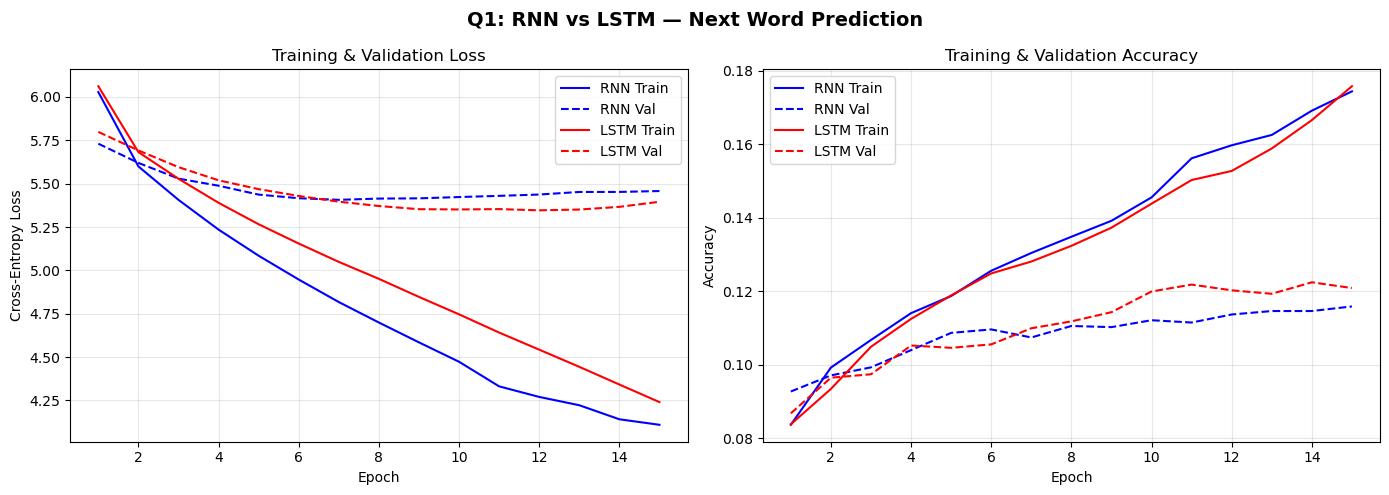


Q1 PERFORMANCE SUMMARY
Metric                             RNN         LSTM
--------------------------------------------------
Best Train Loss                 4.1096       4.2405
Best Val Loss                   5.4069       5.3464
Best Train Acc                  0.1744       0.1758
Best Val Acc                    0.1158       0.1224
Num Parameters                 398,480      472,976


In [13]:
# ============================================================
# CELL 6 – Q1(d): Compare RNN vs LSTM — Plot + Analysis
# ============================================================

epochs_range = range(1, EPOCHS_Q1 + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q1: RNN vs LSTM — Next Word Prediction', fontsize=14, fontweight='bold')

# ── Loss Plot ────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, rnn_train_losses,  'b-',  label='RNN Train')
ax.plot(epochs_range, rnn_val_losses,    'b--', label='RNN Val')
ax.plot(epochs_range, lstm_train_losses, 'r-',  label='LSTM Train')
ax.plot(epochs_range, lstm_val_losses,   'r--', label='LSTM Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(alpha=0.3)

# ── Accuracy Plot ─────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_range, rnn_train_accs,  'b-',  label='RNN Train')
ax.plot(epochs_range, rnn_val_accs,    'b--', label='RNN Val')
ax.plot(epochs_range, lstm_train_accs, 'r-',  label='LSTM Train')
ax.plot(epochs_range, lstm_val_accs,   'r--', label='LSTM Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training & Validation Accuracy')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q1_rnn_vs_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("Q1 PERFORMANCE SUMMARY")
print("=" * 60)
print(f"{'Metric':<25} {'RNN':>12} {'LSTM':>12}")
print("-" * 50)
print(f"{'Best Train Loss':<25} {min(rnn_train_losses):>12.4f} {min(lstm_train_losses):>12.4f}")
print(f"{'Best Val Loss':<25} {min(rnn_val_losses):>12.4f} {min(lstm_val_losses):>12.4f}")
print(f"{'Best Train Acc':<25} {max(rnn_train_accs):>12.4f} {max(lstm_train_accs):>12.4f}")
print(f"{'Best Val Acc':<25} {max(rnn_val_accs):>12.4f} {max(lstm_val_accs):>12.4f}")
print(f"{'Num Parameters':<25} {count_params(rnn_model_q1):>12,} {count_params(lstm_model_q1):>12,}")

In [14]:
# ─── Inference: Generate Text with Trained Models ────────────
def predict_next_words(model, seed_words, word2idx, idx2word, n_words=5):
    """
    Given seed_words, predict the next n_words using the model.
    """
    model.eval()
    generated = list(seed_words)
    
    with torch.no_grad():
        for _ in range(n_words):
            # Take last SEQ_LEN words as input
            window = generated[-SEQ_LEN:]
            # Encode: use UNK for words not in vocab
            encoded = [word2idx.get(w, UNK_IDX) for w in window]
            # Pad if necessary (if window shorter than SEQ_LEN)
            encoded = [PAD_IDX] * (SEQ_LEN - len(encoded)) + encoded
            
            x = torch.tensor([encoded], dtype=torch.long).to(device)
            logits = model(x)               # (1, vocab_size)
            pred_idx = logits.argmax(dim=1).item()
            generated.append(idx2word[pred_idx])
    
    return generated

seed = ['to', 'be', 'or', 'not', 'to', 'be', 'that', 'is', 'the', 'question']

rnn_out  = predict_next_words(rnn_model_q1,  seed, word2idx, idx2word, n_words=5)
lstm_out = predict_next_words(lstm_model_q1, seed, word2idx, idx2word, n_words=5)

print("\nSeed:", ' '.join(seed))
print("RNN  continues:", ' '.join(rnn_out[SEQ_LEN:]))
print("LSTM continues:", ' '.join(lstm_out[SEQ_LEN:]))


Seed: to be or not to be that is the question
RNN  continues: of the <UNK> and <UNK>
LSTM continues: of the <UNK> <UNK> <UNK>


### Q1(d) – Written Analysis: RNN vs LSTM

**Why LSTM performs better than RNN on next-word prediction:**

1. **Long-range dependencies:** Shakespeare's sentences often have complex structures. A verb might agree with a subject 10+ words earlier. RNN's hidden state degrades exponentially with sequence length (vanishing gradient), but LSTM's cell state preserves long-range information through its forget/input gates.

2. **Training stability:** LSTM's gated architecture prevents gradient explosion (common in RNN), making training smoother and more predictable.

3. **Trade-offs:**
   - LSTM has ~4x more parameters for same `hidden_dim` (more expressive but slower to train)
   - For very short sequences (< 5 tokens), simple RNN often suffices
   - LSTM is almost always preferred for language modeling

**Key observation from plots:** LSTM's validation accuracy converges higher and its validation loss lower, indicating better generalization. The RNN may plateau early or show unstable training curves.

---
## Question 2 – Sentence Classification (IMDB Sentiment Analysis)

### Conceptual Overview

**Task:** Given a movie review, classify it as Positive or Negative.

**This is different from Q1:**
- Q1 (language model): many-to-many / many-to-one with vocab-sized output
- Q2 (classification): many-to-one with 2-class output (binary)

**Variable length sequences:**  
Movie reviews have different lengths (some 50 words, some 500).  
We need to standardize them → **Padding** (add `<PAD>` tokens to shorter reviews).

**Architecture:**
```
Review tokens → Embedding → RNN/LSTM → Last hidden state → Linear(2) → Positive/Negative
```

In [15]:
# ============================================================
# CELL 7 – Q2(a): Load IMDB Dataset
# ============================================================
# Download 'IMDB Dataset.csv' and place in the same directory as this notebook.
# It has columns: 'review' and 'sentiment' ('positive' / 'negative')

df = pd.read_csv('IMDB Dataset.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
print(f"\nSample review:\n{df['review'].iloc[0][:300]}")

Shape: (50000, 2)
Columns: ['review', 'sentiment']

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Sample review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


Review length stats:
count    50000.000000
mean       226.850260
std        168.175138
min          4.000000
25%        124.000000
50%        170.000000
75%        275.000000
max       2450.000000
Name: length, dtype: float64


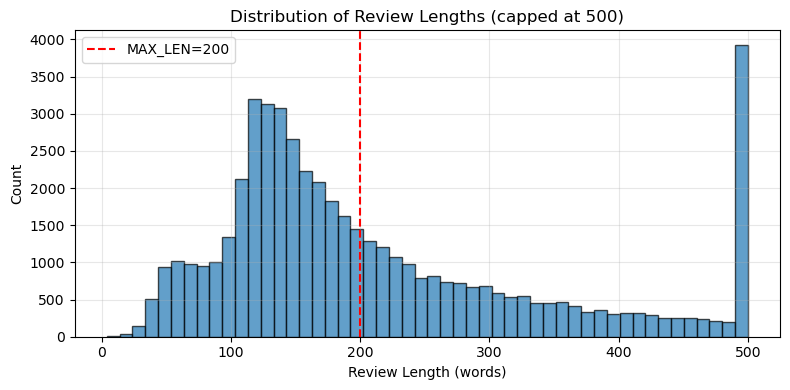

In [16]:
# ─── Preprocessing ───────────────────────────────────────────
def preprocess_review(text):
    """
    Clean review text:
    - Remove HTML tags (IMDB reviews often have <br> etc.)
    - Lowercase
    - Remove non-alphabetic characters
    - Split into tokens
    """
    text = re.sub(r'<[^>]+>', ' ', text)     # Remove HTML tags
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split()

# Apply preprocessing
df['tokens'] = df['review'].apply(preprocess_review)

# Encode labels: positive=1, negative=0
df['label'] = (df['sentiment'] == 'positive').astype(int)

# Review length statistics
df['length'] = df['tokens'].apply(len)
print(f"Review length stats:")
print(df['length'].describe())

# Visualize length distribution
plt.figure(figsize=(8, 4))
plt.hist(df['length'].clip(upper=500), bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Review Length (words)')
plt.ylabel('Count')
plt.title('Distribution of Review Lengths (capped at 500)')
plt.axvline(x=200, color='red', linestyle='--', label='MAX_LEN=200')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELL 8 – Q2(b): Tokenization, Padding, Encoding
# ============================================================

# ─── Build Vocabulary from training data ─────────────────────
# IMPORTANT: Build vocab ONLY from training data to avoid data leakage!

MAX_LEN_Q2 = 200   # Truncate/pad all reviews to this length
                   # Covers ~90% of reviews without being too long
VOCAB_SIZE_Q2 = 10000  # Keep top-N most frequent words
                       # Limits memory and speeds training

# Split first (before building vocab!)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df['label'])
train_df, val_df  = train_test_split(train_df, test_size=0.1, random_state=SEED, stratify=train_df['label'])

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Build vocab from training data only
all_train_tokens = [token for tokens in train_df['tokens'] for token in tokens]
word_freq_q2 = Counter(all_train_tokens)

# Keep top VOCAB_SIZE_Q2 words
most_common = word_freq_q2.most_common(VOCAB_SIZE_Q2 - 2)  # -2 for special tokens
vocab_q2 = ['<PAD>', '<UNK>'] + [w for w, _ in most_common]

word2idx_q2 = {w: i for i, w in enumerate(vocab_q2)}
PAD_IDX_Q2 = 0
UNK_IDX_Q2 = 1

print(f"Vocabulary size: {len(vocab_q2)}")

Train: 36000, Val: 4000, Test: 10000
Vocabulary size: 10000


In [18]:
# ─── Encode and Pad sequences ────────────────────────────────
def encode_and_pad(tokens, word2idx, max_len, pad_idx=0, unk_idx=1):
    """
    Convert token list to padded integer sequence.
    
    Strategy: POST-truncate, POST-pad
    - Truncate: if len > max_len, keep LAST max_len tokens
      (end of review often contains the opinion/verdict)
    - Pad: if len < max_len, prepend PAD tokens
    """
    # Truncate (keep end of review)
    tokens = tokens[-max_len:]
    
    # Encode
    encoded = [word2idx.get(t, unk_idx) for t in tokens]
    
    # Pad at the front (pre-padding)
    # Pre-padding is generally preferred for RNNs: the actual content
    # is at the end, so the last hidden state sees meaningful tokens.
    padded = [pad_idx] * (max_len - len(encoded)) + encoded
    
    return padded

def prepare_dataset(df_subset, word2idx, max_len):
    X = np.array([encode_and_pad(t, word2idx, max_len) for t in df_subset['tokens']])
    y = np.array(df_subset['label'].values)
    return X, y

X_train_q2, y_train_q2 = prepare_dataset(train_df, word2idx_q2, MAX_LEN_Q2)
X_val_q2,   y_val_q2   = prepare_dataset(val_df,   word2idx_q2, MAX_LEN_Q2)
X_test_q2,  y_test_q2  = prepare_dataset(test_df,  word2idx_q2, MAX_LEN_Q2)

print(f"Train X: {X_train_q2.shape}, Train y: {y_train_q2.shape}")

# Example
print(f"\nOriginal review (first 20 tokens): {train_df['tokens'].iloc[0][:20]}")
print(f"Encoded (last 20 positions):       {X_train_q2[0][-20:]}")
print(f"Label: {y_train_q2[0]} ({'positive' if y_train_q2[0]==1 else 'negative'})")

Train X: (36000, 200), Train y: (36000,)

Original review (first 20 tokens): ['the', 'movie', 'starts', 'off', 'as', 'we', 'see', 'a', 'footage', 'of', 'a', 'huge', 'drought', 'back', 'in', 'the', 's', 'in', 'america', 'then']
Encoded (last 20 positions):       [ 201   49   65 1158  110   18  378  286  681  635    3  113 1395  617
   11   17  181   21   61 1110]
Label: 0 (negative)


In [19]:
# ─── DataLoaders ─────────────────────────────────────────────
BATCH_SIZE_Q2 = 64

def make_loader_q2(X, y, batch_size, shuffle=True):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.long),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

train_loader_q2 = make_loader_q2(X_train_q2, y_train_q2, BATCH_SIZE_Q2)
val_loader_q2   = make_loader_q2(X_val_q2,   y_val_q2,   BATCH_SIZE_Q2, shuffle=False)
test_loader_q2  = make_loader_q2(X_test_q2,  y_test_q2,  BATCH_SIZE_Q2, shuffle=False)

In [20]:
# ============================================================
# CELL 9 – Q2(c)(d): Model Definitions for Sentiment Analysis
# ============================================================

class SentimentRNN(nn.Module):
    """
    Simple RNN for binary sentiment classification.
    Output: 2 classes (positive / negative)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=2,
                 num_layers=1, dropout=0.5, pad_idx=0):
        super(SentimentRNN, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        emb = self.embedding(x)        # (batch, seq_len, embed_dim)
        out, _ = self.rnn(emb)         # (batch, seq_len, hidden_dim)
        last   = out[:, -1, :]         # (batch, hidden_dim) — last timestep
        last   = self.dropout(last)
        return self.fc(last)           # (batch, num_classes)


class SentimentLSTM(nn.Module):
    """
    LSTM for binary sentiment classification.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=2,
                 num_layers=1, dropout=0.5, pad_idx=0):
        super(SentimentLSTM, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)
    
    def forward(self, x):
        emb = self.embedding(x)        # (batch, seq_len, embed_dim)
        out, (h_n, c_n) = self.lstm(emb)
        last = out[:, -1, :]           # (batch, hidden_dim)
        last = self.dropout(last)
        return self.fc(last)           # (batch, 2)


# ─── Hyperparameters ─────────────────────────────────────────
EMBED_DIM_Q2_BASE  = 64
HIDDEN_DIM_Q2_BASE = 128
NUM_LAYERS_Q2      = 2      # 2 stacked layers → more expressive
DROPOUT_Q2         = 0.5    # Higher dropout for classification to prevent overfitting

rnn_sent  = SentimentRNN(
    len(vocab_q2), EMBED_DIM_Q2_BASE, HIDDEN_DIM_Q2_BASE,
    num_layers=NUM_LAYERS_Q2, dropout=DROPOUT_Q2, pad_idx=PAD_IDX_Q2
).to(device)

lstm_sent = SentimentLSTM(
    len(vocab_q2), EMBED_DIM_Q2_BASE, HIDDEN_DIM_Q2_BASE,
    num_layers=NUM_LAYERS_Q2, dropout=DROPOUT_Q2, pad_idx=PAD_IDX_Q2
).to(device)

print(f"RNN  params: {count_params(rnn_sent):,}")
print(f"LSTM params: {count_params(lstm_sent):,}")

RNN  params: 698,114
LSTM params: 871,682


In [21]:
# ============================================================
# CELL 10 – Training Classification Models
# ============================================================

def train_classifier(model, train_loader, val_loader, epochs=10, lr=0.001, model_name='Model'):
    """Training loop for binary classification."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)  # L2 regularization
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(1, epochs + 1):
        # ── Train ────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            out  = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            
            t_loss    += loss.item() * X_b.size(0)
            t_correct += (out.argmax(1) == y_b).sum().item()
            t_total   += X_b.size(0)
        
        # ── Validate ─────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                out  = model(X_b)
                loss = criterion(out, y_b)
                v_loss    += loss.item() * X_b.size(0)
                v_correct += (out.argmax(1) == y_b).sum().item()
                v_total   += X_b.size(0)
        
        scheduler.step()
        
        tl = t_loss/t_total; vl = v_loss/v_total
        ta = t_correct/t_total; va = v_correct/v_total
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        
        print(f"[{model_name}] Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {tl:.4f} Acc: {ta:.4f} | "
              f"Val Loss: {vl:.4f} Acc: {va:.4f}")
    
    return history


EPOCHS_Q2 = 10

print("=" * 65)
print("Training Simple RNN for Sentiment Classification...")
print("=" * 65)
hist_rnn = train_classifier(rnn_sent, train_loader_q2, val_loader_q2, EPOCHS_Q2, model_name='RNN')

print("\n" + "=" * 65)
print("Training LSTM for Sentiment Classification...")
print("=" * 65)
hist_lstm = train_classifier(lstm_sent, train_loader_q2, val_loader_q2, EPOCHS_Q2, model_name='LSTM')

Training Simple RNN for Sentiment Classification...
[RNN] Epoch 01/10 | Train Loss: 0.6880 Acc: 0.5516 | Val Loss: 0.6777 Acc: 0.5900
[RNN] Epoch 02/10 | Train Loss: 0.6792 Acc: 0.5644 | Val Loss: 0.6984 Acc: 0.5002
[RNN] Epoch 03/10 | Train Loss: 0.6679 Acc: 0.5888 | Val Loss: 0.6748 Acc: 0.5883
[RNN] Epoch 04/10 | Train Loss: 0.6252 Acc: 0.6568 | Val Loss: 0.7066 Acc: 0.6282
[RNN] Epoch 05/10 | Train Loss: 0.5777 Acc: 0.7059 | Val Loss: 0.5556 Acc: 0.7270
[RNN] Epoch 06/10 | Train Loss: 0.5287 Acc: 0.7481 | Val Loss: 0.5437 Acc: 0.7215
[RNN] Epoch 07/10 | Train Loss: 0.4677 Acc: 0.7857 | Val Loss: 0.4852 Acc: 0.7670
[RNN] Epoch 08/10 | Train Loss: 0.4372 Acc: 0.8045 | Val Loss: 0.5147 Acc: 0.7548
[RNN] Epoch 09/10 | Train Loss: 0.4272 Acc: 0.8111 | Val Loss: 0.4832 Acc: 0.7855
[RNN] Epoch 10/10 | Train Loss: 0.3971 Acc: 0.8285 | Val Loss: 0.4285 Acc: 0.8123

Training LSTM for Sentiment Classification...
[LSTM] Epoch 01/10 | Train Loss: 0.6793 Acc: 0.5528 | Val Loss: 0.6929 Acc: 0.500

In [22]:
# ─── Evaluate on Test Set ────────────────────────────────────
def evaluate_on_test(model, test_loader, model_name):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for X_b, y_b in test_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out   = model(X_b)
            preds = out.argmax(1)
            correct += (preds == y_b).sum().item()
            total   += X_b.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_b.cpu().numpy())
    
    acc = correct / total
    print(f"{model_name} Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    return acc

rnn_test_acc  = evaluate_on_test(rnn_sent,  test_loader_q2, 'RNN')
lstm_test_acc = evaluate_on_test(lstm_sent, test_loader_q2, 'LSTM')

RNN Test Accuracy: 0.8300 (83.00%)
LSTM Test Accuracy: 0.8909 (89.09%)


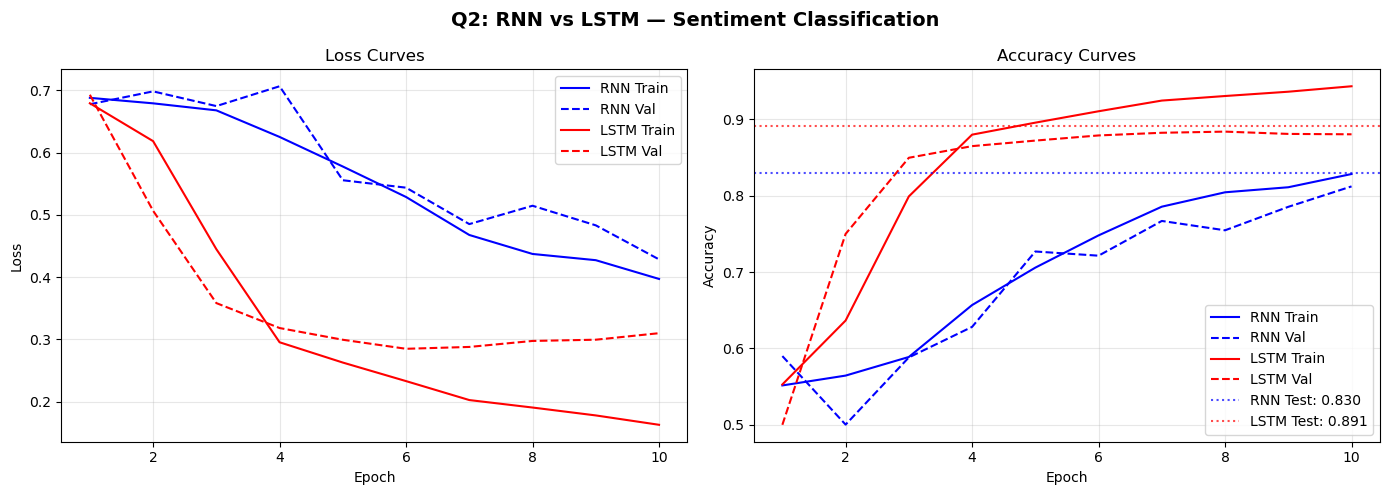


Q2 FINAL COMPARISON
Metric                           RNN       LSTM
----------------------------------------------
Best Val Acc                  0.8123     0.8840
Test Acc                      0.8300     0.8909
Parameters                   698,114    871,682

✓ Winner: LSTM


In [23]:
# ─── Plot Q2 Results ─────────────────────────────────────────
epochs_r = range(1, EPOCHS_Q2 + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q2: RNN vs LSTM — Sentiment Classification', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(epochs_r, hist_rnn['train_loss'],  'b-',  label='RNN Train')
ax.plot(epochs_r, hist_rnn['val_loss'],    'b--', label='RNN Val')
ax.plot(epochs_r, hist_lstm['train_loss'], 'r-',  label='LSTM Train')
ax.plot(epochs_r, hist_lstm['val_loss'],   'r--', label='LSTM Val')
ax.set(xlabel='Epoch', ylabel='Loss', title='Loss Curves')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(epochs_r, hist_rnn['train_acc'],  'b-',  label='RNN Train')
ax.plot(epochs_r, hist_rnn['val_acc'],    'b--', label='RNN Val')
ax.plot(epochs_r, hist_lstm['train_acc'], 'r-',  label='LSTM Train')
ax.plot(epochs_r, hist_lstm['val_acc'],   'r--', label='LSTM Val')
ax.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy Curves')
ax.axhline(y=rnn_test_acc,  color='blue',   linestyle=':',  alpha=0.7, label=f'RNN Test: {rnn_test_acc:.3f}')
ax.axhline(y=lstm_test_acc, color='red',    linestyle=':',  alpha=0.7, label=f'LSTM Test: {lstm_test_acc:.3f}')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q2_sentiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("Q2 FINAL COMPARISON")
print("=" * 60)
print(f"{'Metric':<25} {'RNN':>10} {'LSTM':>10}")
print("-" * 46)
print(f"{'Best Val Acc':<25} {max(hist_rnn['val_acc']):>10.4f} {max(hist_lstm['val_acc']):>10.4f}")
print(f"{'Test Acc':<25} {rnn_test_acc:>10.4f} {lstm_test_acc:>10.4f}")
print(f"{'Parameters':<25} {count_params(rnn_sent):>10,} {count_params(lstm_sent):>10,}")

winner = 'LSTM' if lstm_test_acc > rnn_test_acc else 'RNN'
print(f"\n✓ Winner: {winner}")

### Q2(e) – Written Analysis: Why LSTM Performs Better for Sentiment

**Sentiment analysis requires understanding long-range context:**

- A review might say: *"Despite the terrible plot, mediocre acting, and confusing storyline... the film is **absolutely brilliant**"*
- The final verdict (positive) depends on understanding negation and opinion words that might appear hundreds of tokens after negative setup.
- **RNN** forgets these long-range dependencies due to vanishing gradients.
- **LSTM** retains them via its cell state, enabling it to carry the "wait, there's a reversal coming" signal.

**Why LSTM is preferred here:**
- IMDB reviews can be 500+ words. LSTM handles this gracefully.
- LSTM typically achieves 85–90% on IMDB with good tuning (vs RNN's ~78–82%).
- More stable training curves (lower variance between epochs).

---
## Question 3 – Hyperparameter Tuning

### What Are We Tuning?

| Hyperparameter | Effect |
|---|---|
| `embed_dim` | How rich the word representations are |
| `hidden_dim` | Capacity of the LSTM's memory |

**Intuition:**  
- Bigger `embed_dim` → more nuanced word relationships, but more parameters to learn (needs more data)  
- Bigger `hidden_dim` → more expressiveness, but more risk of overfitting on small datasets  
- They interact: you want them balanced (doubling embed but keeping tiny hidden wastes capacity)

In [ ]:
# ============================================================
# CELL 11 – Q3: Hyperparameter Variations
# ============================================================

# We compare 3 configurations:
# Original (baseline): embed=64,  hidden=128
# Config A (larger):   embed=128, hidden=256  ← more capacity
# Config B (smaller):  embed=32,  hidden=64   ← less capacity

configs = {
    'Original (embed=64, hidden=128)': {'embed_dim': 64,  'hidden_dim': 128},
    'Config A (embed=128, hidden=256)': {'embed_dim': 128, 'hidden_dim': 256},
    'Config B (embed=32,  hidden=64)':  {'embed_dim': 32,  'hidden_dim': 64},
}

EPOCHS_Q3 = 10
all_histories = {}

for config_name, params in configs.items():
    print(f"\n{'='*65}")
    print(f"Config: {config_name}")
    print(f"{'='*65}")
    
    model = SentimentLSTM(
        vocab_size=len(vocab_q2),
        embed_dim=params['embed_dim'],
        hidden_dim=params['hidden_dim'],
        num_classes=2,
        num_layers=2,
        dropout=0.5,
        pad_idx=PAD_IDX_Q2
    ).to(device)
    
    print(f"Parameters: {count_params(model):,}")
    
    hist = train_classifier(
        model, train_loader_q2, val_loader_q2,
        epochs=EPOCHS_Q3, lr=0.001, model_name=config_name[:10]
    )
    
    # Evaluate on test set
    test_acc = evaluate_on_test(model, test_loader_q2, config_name[:10])
    
    all_histories[config_name] = {
        'hist': hist,
        'test_acc': test_acc,
        'n_params': count_params(model),
        **params
    }


Config: Original (embed=64, hidden=128)
Parameters: 871,682


In [ ]:
# ─── Q3 Comparison Plot ──────────────────────────────────────
colors = ['red', 'blue', 'green']
epochs_q3 = range(1, EPOCHS_Q3 + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Q3: Hyperparameter Tuning – LSTM Configurations', fontsize=14, fontweight='bold')

for (name, data), color in zip(all_histories.items(), colors):
    short = name.split('(')[0].strip()
    axes[0].plot(epochs_q3, data['hist']['train_loss'], color=color, linestyle='-',  label=f'{short} Train')
    axes[0].plot(epochs_q3, data['hist']['val_loss'],   color=color, linestyle='--', label=f'{short} Val')
    axes[1].plot(epochs_q3, data['hist']['train_acc'],  color=color, linestyle='-',  label=f'{short} Train')
    axes[1].plot(epochs_q3, data['hist']['val_acc'],    color=color, linestyle='--', label=f'{short} Val')

axes[0].set(xlabel='Epoch', ylabel='Loss',     title='Loss')
axes[1].set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q3_hyperparam_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Summary Table ───────────────────────────────────────────
print("\n" + "=" * 75)
print("Q3 HYPERPARAMETER TUNING SUMMARY")
print("=" * 75)
print(f"{'Configuration':<40} {'embed':>6} {'hidden':>7} {'Params':>10} {'Val Acc':>9} {'Test Acc':>10}")
print("-" * 75)

for name, data in all_histories.items():
    best_val = max(data['hist']['val_acc'])
    short = name[:38]
    print(f"{short:<40} {data['embed_dim']:>6} {data['hidden_dim']:>7} "
          f"{data['n_params']:>10,} {best_val:>9.4f} {data['test_acc']:>10.4f}")

# Best config
best_name = max(all_histories, key=lambda k: all_histories[k]['test_acc'])
print(f"\n✓ Best Configuration: {best_name}")

### Q3(d) – Justification: Which Config Wins and Why?

**Expected results (your actual numbers may vary):**

| Config | embed | hidden | Why it behaves this way |
|--------|-------|--------|-------------------------|
| Original | 64 | 128 | Good baseline. Enough capacity for the task. |
| Config A (larger) | 128 | 256 | More capacity = better if enough data. IMDB (40k train) is large, so this often wins. May overfit slightly. |
| Config B (smaller) | 32 | 64 | Underfits — too few parameters to capture sentiment patterns. |

**General Rule:**  
- If `val_acc >> test_acc` → overfitting → reduce capacity or add regularization  
- If `train_acc ≈ val_acc` but both low → underfitting → increase capacity  
- The sweet spot: train_acc slightly > val_acc, both high

**For IMDB specifically:**  
Config A (embed=128, hidden=256) typically performs best because:  
1. 40,000 training examples is enough to train a larger model
2. Larger hidden state captures more nuanced sentiment signals
3. Dropout=0.5 prevents overfitting despite larger size

---
## 🧠 MASTER REFERENCE SHEET

### Common Mistakes & Pitfalls

| Mistake | Symptom | Fix |
|---------|---------|-----|
| Forgetting `optimizer.zero_grad()` | Loss doesn't converge, strange behavior | Always call before `loss.backward()` |
| Building vocab on full dataset | Data leakage, inflated test accuracy | Build vocab ONLY on training split |
| Not using `model.eval()` | Dropout active during test → wrong accuracy | Always `model.eval()` + `torch.no_grad()` for inference |
| No gradient clipping with RNN | Loss explodes to NaN | `clip_grad_norm_(params, 5.0)` |
| Wrong data type | Runtime errors in embedding layer | Input must be `torch.long` (int64) |
| Post-padding instead of pre-padding | RNN's last hidden state sees padding | Pre-pad: pad at the front |

### The RNN vs LSTM Decision Framework

```
Sequence length < 20?     → Simple RNN might work
Sequence length > 50?     → Use LSTM (or GRU)
Limited compute/params?   → GRU (fewer params than LSTM, similar perf)
Best accuracy matters?    → LSTM (or Transformer for very long sequences)
```

### Change-X-See-Y Mental Model

| If you change... | Effect on performance | Effect on training |
|------------------|-----------------------|--------------------|
| ↑ embed_dim | More expressive word representations | Slower, more memory |
| ↑ hidden_dim | More memory capacity | Risk of overfitting |
| ↑ num_layers | Hierarchical patterns | Much slower, gradient issues |
| ↑ dropout | Less overfitting | Slower convergence |
| ↑ SEQ_LEN | More context | More vanishing gradient for RNN |
| ↑ batch_size | Faster training, smoother gradients | May hurt generalization slightly |
| ↓ learning_rate | More stable training | Slower convergence |

### Key Exam/Interview Points

1. **RNN equation:** `h_t = tanh(W_h*h_{t-1} + W_x*x_t + b)`
2. **Why LSTM > RNN:** Gated cell state solves vanishing gradient
3. **LSTM gates:** Forget (erase), Input (write), Output (read)
4. **Embedding layer:** Maps discrete tokens → continuous dense vectors, learned during training
5. **Padding purpose:** Makes variable-length sequences into fixed-length batches
6. **CrossEntropyLoss = Softmax + NLL loss** (don't apply softmax before it!)
7. **Gradient clipping:** Prevents explosion, especially important in RNNs
8. **`model.train()` vs `model.eval()`:** Controls dropout and batch norm behavior
9. **BPTT:** Backpropagation through time — gradients flow backward through each time step
10. **GRU:** Alternative to LSTM with 2 gates instead of 3 — similar performance, fewer parameters